# Supply Chain Network Selection Using Mixture and Clustering
*Supply Chain data of Sales Order, Production, Factory Issue and Delivery to Distributer Costs in unit.*
**Sales Order and Production amount is the main variables.**
## Objective ##
- Presenting Sales Order and Production unit analysis for future conditions.
- Hidden dynamics of data of the selected variables.
- Factory Issue and Delivery to Distributer require to stimulate of analysis the Sales Order and Production quantity.


##                                    Selection of Machine Learning Model ##

###                                     **Gaussian Mixture Model** ###

#### Objective 
- After MILP, the selected networks production and sales order unit distributed in probabilistic method which is shown by GMM.
- By predictive analysis, GMM and BGMM identify the upcoming conditions of specific networks which is work on. 



In [52]:
#Modules
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np 
from sklearn.mixture import (
    BayesianGaussianMixture, 
    GaussianMixture
)
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
#Feature Extraction for GMM and BGMM
dataset = pd.read_csv("Data\\train\\MAR01K24P training data.csv")
so_pd_dd_fi_dataset = dataset.loc[:, ["Production", "Delivery to Distributer", "Factory Issue", "Sales Order"]]
X = np.array(so_pd_dd_fi_dataset)
X.shape

(221, 4)

In [54]:
#Training the models
n_components = 20
def scoring(estimator, X):
    return  estimator.bic(X)

model = GridSearchCV(
    estimator=BayesianGaussianMixture(),
    param_grid={
        "n_components": [n_components], 
        "covariance_type": ["full"], 
        "weight_concentration_prior": [1/n_components],
        "weight_concentration_prior_type": ['dirichlet_distribution'],
        "init_params": ['k-means++'],
    },
    scoring= scoring
)
model.fit(X)

GridSearchCV(estimator=BayesianGaussianMixture(),
             param_grid={'covariance_type': ['full'],
                         'init_params': ['k-means++'], 'n_components': [20],
                         'weight_concentration_prior': [0.05],
                         'weight_concentration_prior_type': ['dirichlet_distribution']},
             scoring=<function scoring at 0x0000027FB2B42A20>)

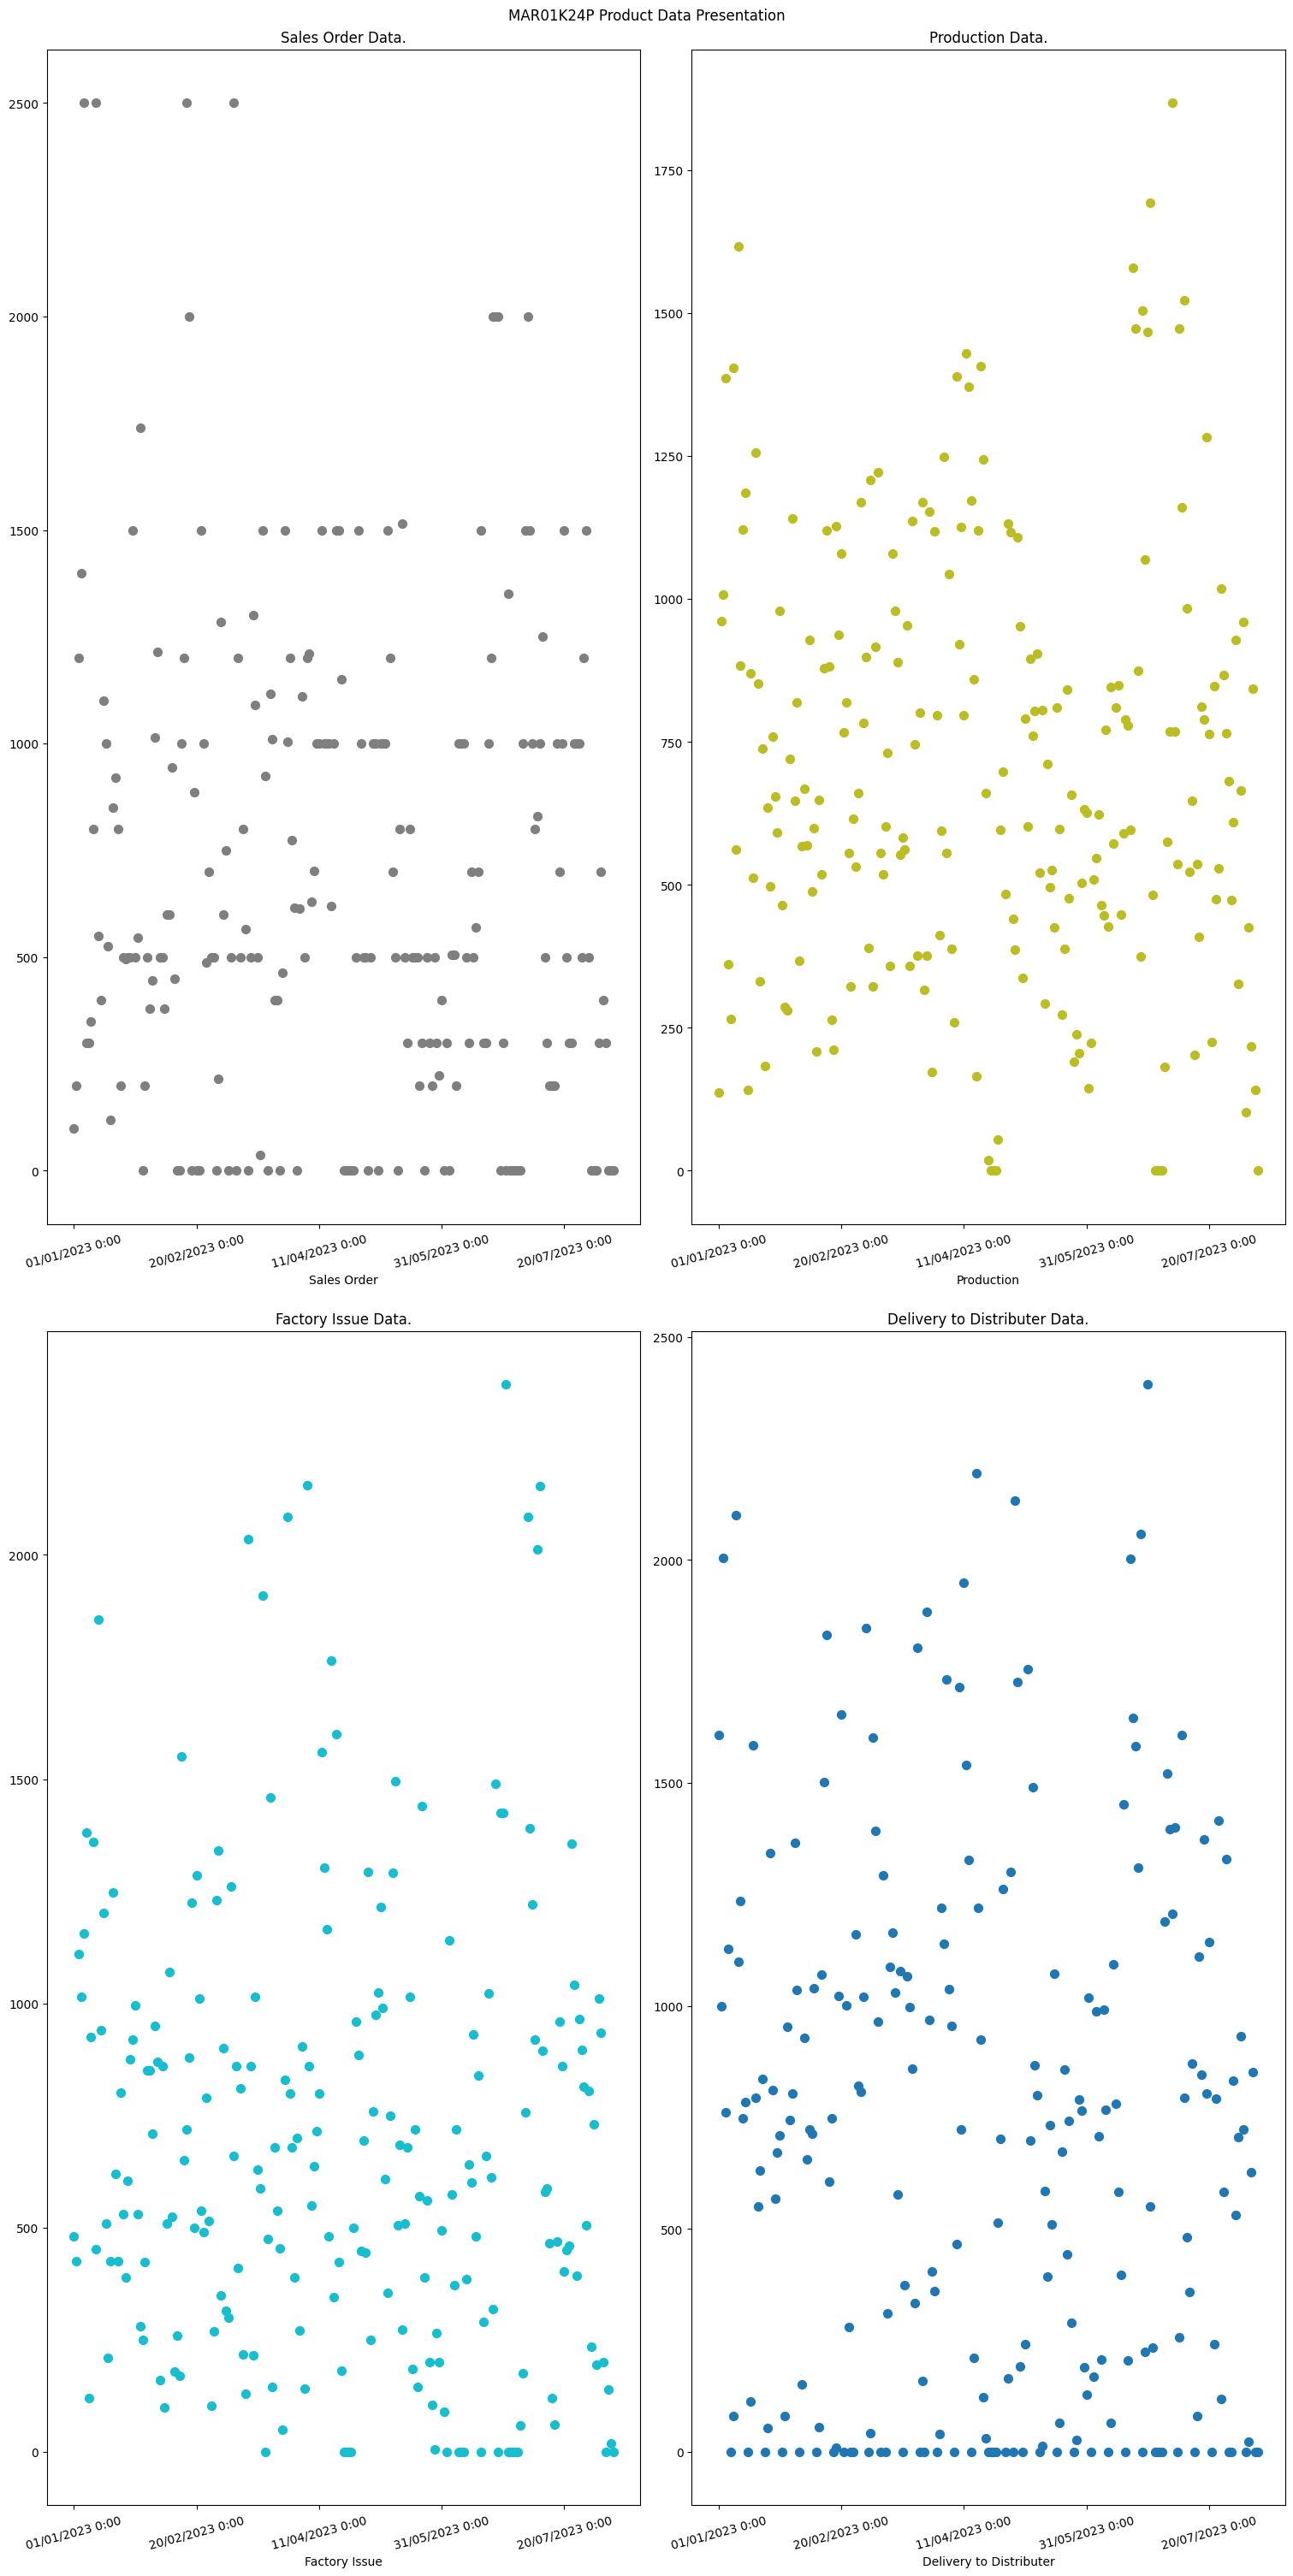

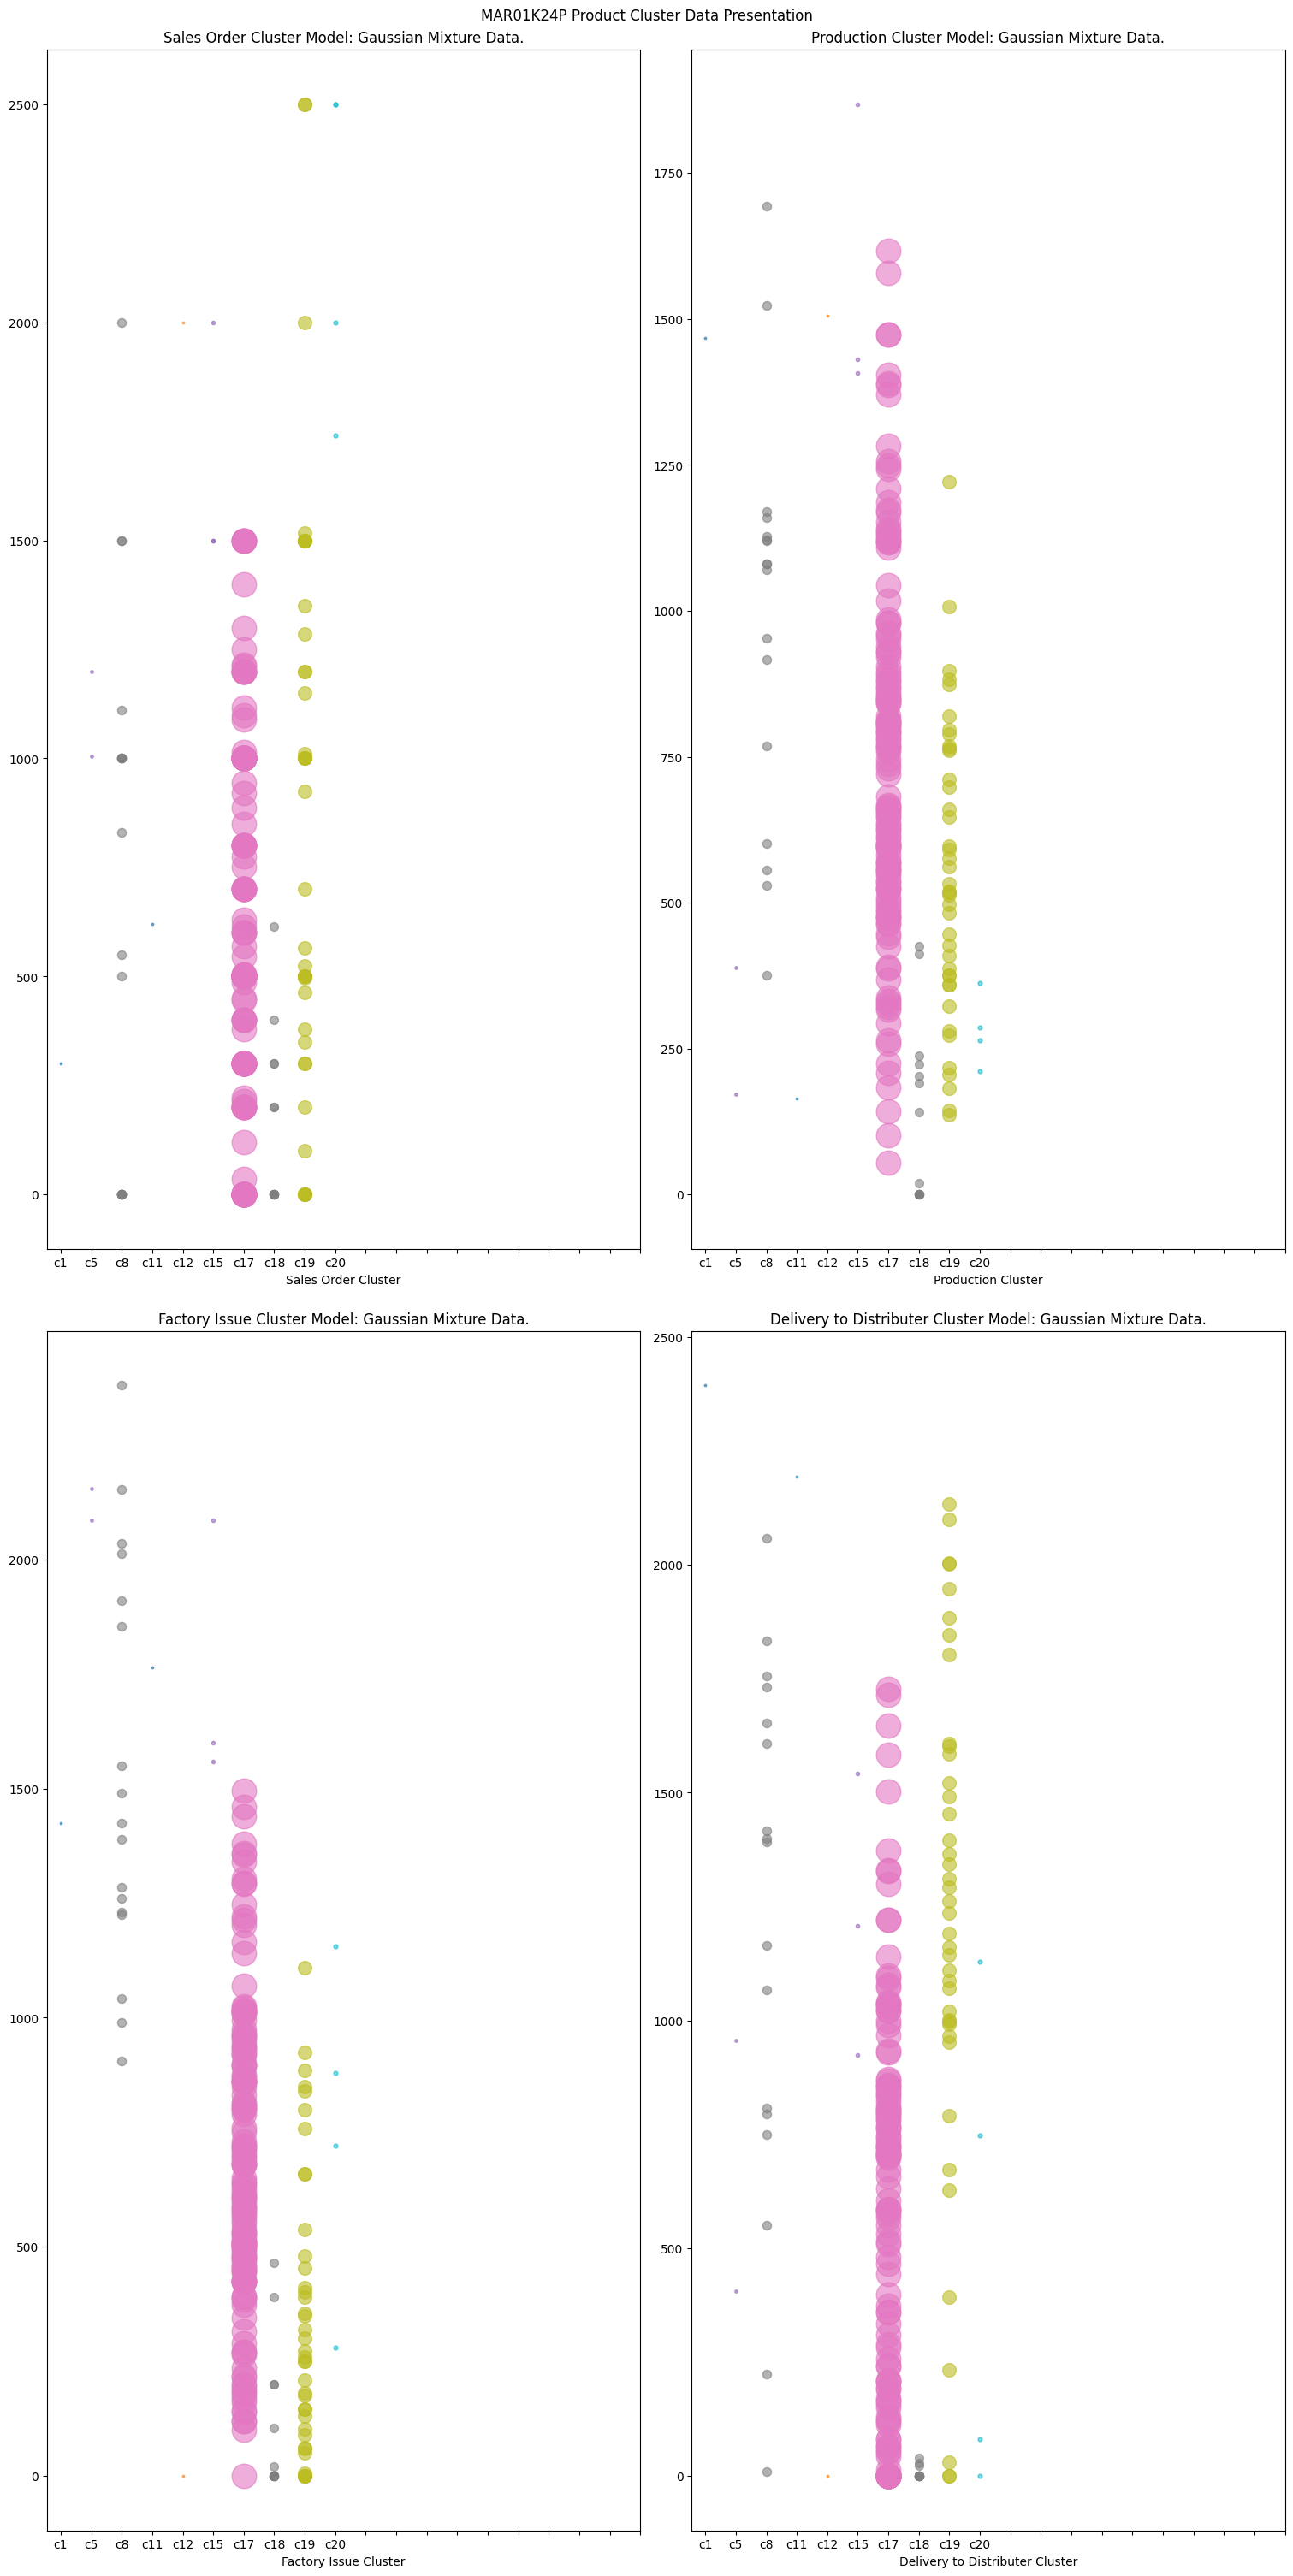

<Figure size 640x480 with 0 Axes>

In [ ]:
#Visualization and Presentation of Cluster Data
def presentation_analysis(estimator, model_name:str):
    data_after_cluster = {}
    c_n_list = []
    l_list = []
    c_d = []
    c_d_c = []
    m_data = []
    range_data = []
    v_name_list = []

    fig_name_list = ["Sales Order", "Production","Factory Issue", "Delivery to Distributer",
                                    "Sales Order Cluster", "Production Cluster",
                                    "Factory Issue Cluster", "Delivery to Distributer Cluster"]

    colors = sns.color_palette(n_colors=n_components)
    x_dates = np.array(dataset.loc[:, ["Date"] ]).reshape(-1)

    dimentions = X.shape[1]*2
    fig1 = plt.figure(num=2*dimentions,figsize=(15, 30), layout="constrained")
    
    axs1 = fig1.subplot_mosaic(mosaic=[["Sales Order", "Production"],
                                    ["Factory Issue", "Delivery to Distributer"]])
    
    fig1.suptitle(t=f"{dataset['Product Code'].values[0]} Product Data Presentation")
    for  n in range(0, dimentions-4):
        fig_name = fig_name_list[n]
        color = colors[n-3]
        axs1[fig_name].set_title(f"{fig_name} Data.")
        axs1[fig_name].scatter(x_dates,X[:, n], s=50, color=color, alpha=1.0)
        axs1[fig_name].set_xlabel(fig_name)
        axs1[fig_name].set_xticks(rotation=15,ticks=[i for i in range(0, len(x_dates), 50)],  labels=[x_dates[i] for i in range(0, len(x_dates), 50)])
    plt.show()


    fig2 = plt.figure(num=2*dimentions,figsize=(15, 30), layout="constrained")
    axs2 = fig2.subplot_mosaic(mosaic=  [["Sales Order Cluster", "Production Cluster"],
                                    ["Factory Issue Cluster", "Delivery to Distributer Cluster"]])
    fig2.suptitle(t=f"{dataset['Product Code'].values[0]} Product Cluster Data Presentation")

    X_predict = estimator.predict(X)

    for  n in range(4, dimentions):
        fig_name = fig_name_list[n]
        color = colors[n-3]
        axs2[fig_name].set_title(f"{fig_name} Model: {model_name} Data.")
        for i , color in enumerate(colors):
            if not np.any(X_predict == i):
                continue

            Y = X[X_predict == i, n-4]
            length = len(Y)
            c_name = f"c{i+1}"
            c_n_list.append(c_name)
            c_d_c.append(str(x_dates[X_predict == i]))
            l_list.append(length)
            c_d.append(str(Y))
            m_data.append(max(Y))
            range_data.append(max(Y)-min(Y))
            v_name_list.append(fig_name)

            area = np.pi * length
            axs2[fig_name].scatter([f"{c_name}" for j in range(0, length)],Y, s=area, color=color, alpha=0.6)
            axs2[fig_name].set_xlabel(fig_name)
            axs2[fig_name].set_xticks(ticks=[i for i in range(0, n_components, 1)])            
    
        data_after_cluster['Variable Name'] = v_name_list
        data_after_cluster['Cluster Name'] = c_n_list
        data_after_cluster['Cluster Length'] = l_list
        data_after_cluster['Cluster Data'] = c_d
        data_after_cluster['Cluster Date'] = c_d_c
        data_after_cluster["Range Length"] = range_data
        """data_after_cluster['Maximum Lenth'] = max(l_list)"""
        data_after_cluster['Maximum Data'] = m_data
    plt.show() 
    return pd.DataFrame(data_after_cluster)

data_after_cluster = presentation_analysis(model, model_name="Gaussian Mixture")

In [56]:
#Cluster Data Save as Json format
import json as js
product_code = dataset['Product Code'].values[0]
data_selected = data_after_cluster.loc[data_after_cluster["Variable Name"]== "Production Cluster"]
sort_cluster = sorted(data_selected['Cluster Length'], reverse=True)[:5]
data_selected = data_selected.loc[data_selected['Cluster Length'].values >= min(sort_cluster) ]#
data_selected.to_json(f"Data\\cluster\\{product_code} Cluster.json", index=False, orient="records", indent=5)

In [57]:
data_selected.to_json(f"Data\\cluster\\{product_code} Cluster.json", index=False, orient="records", indent=5)